In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine, make_moons, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
def sigmoid(x):     return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
def sigmoid_d(x):   s = sigmoid(x); return s * (1 - s)

def tanh(x):        return np.tanh(x)
def tanh_d(x):      return 1 - np.tanh(x)**2

def relu(x):        return np.maximum(0, x)
def relu_d(x):      return (x > 0).astype(float)

def softmax(x):
    e = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

ACTIVATIONS = {
    'sigmoid': (sigmoid, sigmoid_d),
    'tanh':    (tanh,    tanh_d),
    'relu':    (relu,    relu_d),
}

print("Activation functions ready.")


Activation functions ready.


In [3]:
wine = load_wine()

# Take only 2 classes (binary like your perceptron expects)
X_lin = wine.data[wine.target != 2][:, :2]
y_lin = wine.target[wine.target != 2].reshape(-1, 1)

# Non-linear dataset (moons)
X_nl, y_nl = make_moons(n_samples=300, noise=0.2, random_state=42)
y_nl = y_nl.reshape(-1, 1)

scaler = StandardScaler()
X_lin = scaler.fit_transform(X_lin)
X_nl  = scaler.fit_transform(X_nl)

print("Linear dataset:", X_lin.shape, y_lin.shape)
print("Non-linear dataset:", X_nl.shape, y_nl.shape)



Linear dataset: (130, 2) (130, 1)
Non-linear dataset: (300, 2) (300, 1)


In [4]:
class SingleLayerPerceptron:
    def __init__(self, input_size, activation='sigmoid', use_bias=True):
        self.use_bias = use_bias
        self.act, self.act_d = ACTIVATIONS[activation]
        self.W = np.random.randn(input_size, 1) * 0.01
        self.b = np.zeros((1, 1)) if use_bias else None

    def forward(self, X):
        self.z = X @ self.W + (self.b if self.use_bias else 0)
        self.a = self.act(self.z)
        return self.a

    def train(self, X, y, lr=0.1, epochs=500):
        losses = []
        for _ in range(epochs):
            out = self.forward(X)
            err = out - y
            loss = np.mean(err**2)
            losses.append(loss)
            dW = X.T @ (err * self.act_d(self.z)) / len(X)
            self.W -= lr * dW
            if self.use_bias:
                self.b -= lr * np.mean(err * self.act_d(self.z), axis=0, keepdims=True)
        return losses

    def predict(self, X):
        return (self.forward(X) >= 0.5).astype(int)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

In [5]:
print("="*60)
print("SINGLE LAYER PERCEPTRON RESULTS")
print("="*60)

for dataset_name, X_d, y_d in [('Linear', X_lin, y_lin), ('Non-linear', X_nl, y_nl)]:
    for bias in [True, False]:
        for act in ['sigmoid', 'tanh', 'relu']:
            slp = SingleLayerPerceptron(X_d.shape[1], activation=act, use_bias=bias)
            losses = slp.train(X_d, y_d, lr=0.05, epochs=500)
            acc = slp.accuracy(X_d, y_d)
            print(f"{dataset_name:12} | Bias={str(bias):5} | {act:7} | Acc={acc:.4f} | Loss={losses[-1]:.4f}")

SINGLE LAYER PERCEPTRON RESULTS
Linear       | Bias=True  | sigmoid | Acc=0.9231 | Loss=0.0965
Linear       | Bias=True  | tanh    | Acc=0.9000 | Loss=0.0865
Linear       | Bias=True  | relu    | Acc=0.9385 | Loss=0.0762
Linear       | Bias=False | sigmoid | Acc=0.9231 | Loss=0.0982
Linear       | Bias=False | tanh    | Acc=0.6077 | Loss=0.3693
Linear       | Bias=False | relu    | Acc=0.8385 | Loss=0.1558
Non-linear   | Bias=True  | sigmoid | Acc=0.8567 | Loss=0.1076
Non-linear   | Bias=True  | tanh    | Acc=0.8667 | Loss=0.1036
Non-linear   | Bias=True  | relu    | Acc=0.8667 | Loss=0.0955
Non-linear   | Bias=False | sigmoid | Acc=0.8567 | Loss=0.1078
Non-linear   | Bias=False | tanh    | Acc=0.6333 | Loss=0.3449
Non-linear   | Bias=False | relu    | Acc=0.8233 | Loss=0.1559


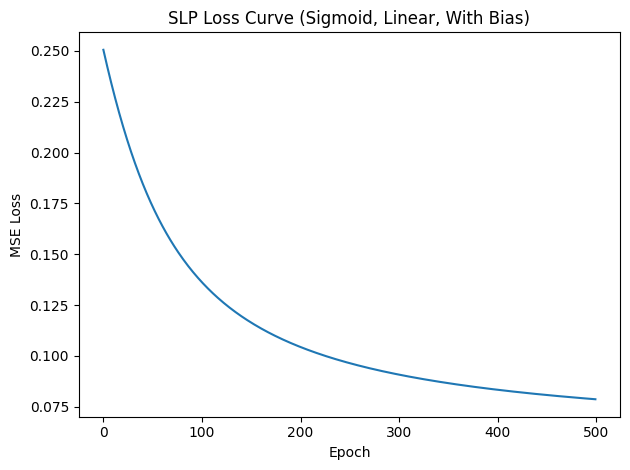

In [6]:
slp_plot = SingleLayerPerceptron(X_lin.shape[1], activation='sigmoid', use_bias=True)
losses_plot = slp_plot.train(X_lin, y_lin, epochs=500)

plt.plot(losses_plot)
plt.title("SLP Loss Curve (Sigmoid, Linear, With Bias)")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.tight_layout(); plt.show()


In [7]:
class BackpropNetwork:
    def __init__(self, input_size, hidden_size, output_size, activation='sigmoid', use_bias=True):
        self.use_bias = use_bias
        self.act, self.act_d = ACTIVATIONS[activation]

        self.W1 = np.random.randn(input_size, hidden_size) * 0.1
        self.W2 = np.random.randn(hidden_size, output_size) * 0.1
        self.b1 = np.zeros((1, hidden_size)) if use_bias else 0
        self.b2 = np.zeros((1, output_size)) if use_bias else 0

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.act(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = sigmoid(self.z2)       # output layer always sigmoid
        return self.a2

    def train(self, X, y, lr=0.05, epochs=500):
        losses = []
        for _ in range(epochs):
            out = self.forward(X)
            err = out - y
            loss = np.mean(err**2)
            losses.append(loss)

            # Backprop
            d2 = err * sigmoid_d(self.z2)
            dW2 = self.a1.T @ d2 / len(X)
            db2 = np.mean(d2, axis=0, keepdims=True)

            d1 = (d2 @ self.W2.T) * self.act_d(self.z1)
            dW1 = X.T @ d1 / len(X)
            db1 = np.mean(d1, axis=0, keepdims=True)

            self.W2 -= lr * dW2
            self.W1 -= lr * dW1
            if self.use_bias:
                self.b2 -= lr * db2
                self.b1 -= lr * db1
        return losses

    def predict(self, X):
        out = self.forward(X)
        if out.shape[1] == 1:
            return (out >= 0.5).astype(int)
        return np.argmax(out, axis=1)

    def accuracy(self, X, y):
        pred = self.predict(X)
        if y.shape[1] == 1:
            return np.mean(pred == y)
        return np.mean(pred == np.argmax(y, axis=1))


In [8]:
print("="*60)
print("BACKPROPAGATION - SINGLE OUTPUT")
print("="*60)

for dataset_name, X_d, y_d in [('Linear', X_lin, y_lin), ('Non-linear', X_nl, y_nl)]:
    for bias in [True, False]:
        for act in ['sigmoid', 'tanh', 'relu']:
            bp = BackpropNetwork(X_d.shape[1], 8, 1, activation=act, use_bias=bias)
            losses = bp.train(X_d, y_d, lr=0.05, epochs=500)
            acc = bp.accuracy(X_d, y_d)
            print(f"{dataset_name:12} | Bias={str(bias):5} | {act:7} | Acc={acc:.4f} | Loss={losses[-1]:.4f}")


BACKPROPAGATION - SINGLE OUTPUT
Linear       | Bias=True  | sigmoid | Acc=0.5462 | Loss=0.2435
Linear       | Bias=True  | tanh    | Acc=0.9000 | Loss=0.1189
Linear       | Bias=True  | relu    | Acc=0.8692 | Loss=0.1803
Linear       | Bias=False | sigmoid | Acc=0.5462 | Loss=0.2342
Linear       | Bias=False | tanh    | Acc=0.9231 | Loss=0.1087
Linear       | Bias=False | relu    | Acc=0.9154 | Loss=0.2335
Non-linear   | Bias=True  | sigmoid | Acc=0.5067 | Loss=0.2476
Non-linear   | Bias=True  | tanh    | Acc=0.8567 | Loss=0.1289
Non-linear   | Bias=True  | relu    | Acc=0.8500 | Loss=0.1975
Non-linear   | Bias=False | sigmoid | Acc=0.8267 | Loss=0.2340
Non-linear   | Bias=False | tanh    | Acc=0.8633 | Loss=0.1229
Non-linear   | Bias=False | relu    | Acc=0.8633 | Loss=0.1834


In [11]:
wine_full = load_wine()
X_m = scaler.fit_transform(wine_full.data)
y_m_raw = wine_full.target
y_m = np.eye(3)[y_m_raw]

print("\n" + "="*60)
print("BACKPROPAGATION - MULTIPLE OUTPUT (3 classes)")
print("="*60)

for bias in [True, False]:
    for act in ['sigmoid', 'tanh', 'relu']:
        bp = BackpropNetwork(13, 8, 3, activation=act, use_bias=bias)
        losses = bp.train(X_m, y_m, lr=0.05, epochs=500)
        acc = bp.accuracy(X_m, y_m)
        print(f"Bias={str(bias):5} | {act:7} | Acc={acc:.4f} | Loss={losses[-1]:.4f}")



BACKPROPAGATION - MULTIPLE OUTPUT (3 classes)
Bias=True  | sigmoid | Acc=0.6966 | Loss=0.1876
Bias=True  | tanh    | Acc=0.9888 | Loss=0.0443
Bias=True  | relu    | Acc=0.9775 | Loss=0.0314
Bias=False | sigmoid | Acc=0.6124 | Loss=0.1831
Bias=False | tanh    | Acc=0.9775 | Loss=0.0643
Bias=False | relu    | Acc=0.9551 | Loss=0.0519


In [12]:
class MLP:
    def __init__(self, layer_sizes, activation='relu', use_bias=True):
        # layer_sizes = [input, hidden1, hidden2, output]
        self.use_bias = use_bias
        self.act, self.act_d = ACTIVATIONS[activation]
        self.weights = []
        self.biases  = []
        for i in range(len(layer_sizes) - 1):
            self.weights.append(np.random.randn(layer_sizes[i], layer_sizes[i+1]) * 0.1)
            self.biases.append(np.zeros((1, layer_sizes[i+1])) if use_bias else 0)

    def forward(self, X):
        self.zs = []; self.as_ = [X]
        a = X
        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            z = a @ W + b
            self.zs.append(z)
            # last layer: sigmoid; hidden layers: chosen activation
            a = sigmoid(z) if i == len(self.weights)-1 else self.act(z)
            self.as_.append(a)
        return a

    def train(self, X, y, lr=0.01, epochs=500):
        losses = []
        for _ in range(epochs):
            out = self.forward(X)
            loss = np.mean((out - y)**2)
            losses.append(loss)

            # Backprop through all layers
            delta = (out - y) * sigmoid_d(self.zs[-1])
            grads_W = [None] * len(self.weights)
            grads_b = [None] * len(self.biases)

            for i in reversed(range(len(self.weights))):
                grads_W[i] = self.as_[i].T @ delta / len(X)
                grads_b[i] = np.mean(delta, axis=0, keepdims=True)
                if i > 0:
                    delta = (delta @ self.weights[i].T) * self.act_d(self.zs[i-1])

            for i in range(len(self.weights)):
                self.weights[i] -= lr * grads_W[i]
                if self.use_bias:
                    self.biases[i] -= lr * grads_b[i]
        return losses

    def predict(self, X):
        out = self.forward(X)
        if out.shape[1] == 1:
            return (out >= 0.5).astype(int)
        return np.argmax(out, axis=1)

    def accuracy(self, X, y):
        pred = self.predict(X)
        if y.shape[1] == 1:
            return np.mean(pred == y)
        return np.mean(pred == np.argmax(y, axis=1))

In [13]:
print("="*60)
print("MLP - MULTIPLE OUTPUT (binary wrapped as 1 output shown)")
print("="*60)

for dataset_name, X_d, y_d in [('Linear', X_lin, y_lin), ('Non-linear', X_nl, y_nl)]:
    for bias in [True, False]:
        for act in ['sigmoid', 'tanh', 'relu']:
            mlp = MLP([X_d.shape[1], 8, 4, 1], activation=act, use_bias=bias)
            losses = mlp.train(X_d, y_d, lr=0.05, epochs=500)
            acc = mlp.accuracy(X_d, y_d)
            print(f"{dataset_name:12} | Bias={str(bias):5} | {act:7} | Acc={acc:.4f} | Loss={losses[-1]:.4f}")


MLP - MULTIPLE OUTPUT (binary wrapped as 1 output shown)
Linear       | Bias=True  | sigmoid | Acc=0.5462 | Loss=0.2478
Linear       | Bias=True  | tanh    | Acc=0.5462 | Loss=0.2382
Linear       | Bias=True  | relu    | Acc=0.5462 | Loss=0.2446
Linear       | Bias=False | sigmoid | Acc=0.5462 | Loss=0.2480
Linear       | Bias=False | tanh    | Acc=0.9231 | Loss=0.2425
Linear       | Bias=False | relu    | Acc=0.5846 | Loss=0.2495
Non-linear   | Bias=True  | sigmoid | Acc=0.5000 | Loss=0.2500
Non-linear   | Bias=True  | tanh    | Acc=0.8433 | Loss=0.2391
Non-linear   | Bias=True  | relu    | Acc=0.8400 | Loss=0.2427
Non-linear   | Bias=False | sigmoid | Acc=0.5000 | Loss=0.2501
Non-linear   | Bias=False | tanh    | Acc=0.8200 | Loss=0.2383
Non-linear   | Bias=False | relu    | Acc=0.7900 | Loss=0.2489


In [15]:
print("\n" + "="*60)
print("MLP - MULTI-CLASS (Wine 3 outputs)")
print("="*60)

for bias in [True, False]:
    for act in ['sigmoid', 'tanh', 'relu']:
        mlp = MLP([13, 16, 8, 3], activation=act, use_bias=bias)
        losses = mlp.train(X_m, y_m, lr=0.05, epochs=500)
        acc = mlp.accuracy(X_m, y_m)
        print(f"Bias={str(bias):5} | {act:7} | Acc={acc:.4f} | Loss={losses[-1]:.4f}")



MLP - MULTI-CLASS (Wine 3 outputs)
Bias=True  | sigmoid | Acc=0.3989 | Loss=0.2193
Bias=True  | tanh    | Acc=0.9775 | Loss=0.0809
Bias=True  | relu    | Acc=0.8315 | Loss=0.1528
Bias=False | sigmoid | Acc=0.3989 | Loss=0.2194
Bias=False | tanh    | Acc=0.9719 | Loss=0.0887
Bias=False | relu    | Acc=0.7135 | Loss=0.1871


Digit images shape: (1797, 64)
Classes: [0 1 2 3 4 5 6 7 8 9]


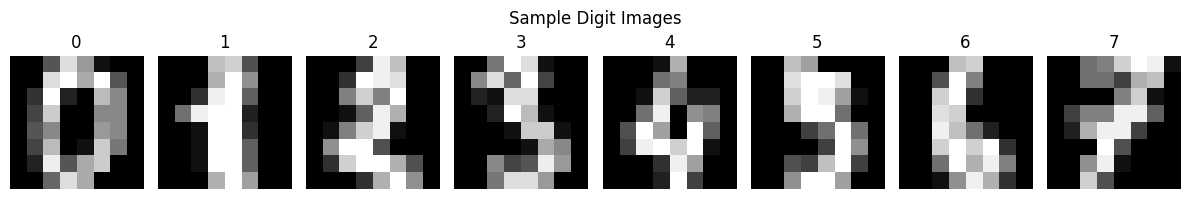

In [16]:
digits = load_digits()
X_dig = digits.data / 16.0                 # normalize to [0, 1]
y_dig_raw = digits.target
y_dig = np.eye(10)[y_dig_raw]              # one-hot encode (10 classes)

X_tr, X_te, y_tr, y_te = train_test_split(X_dig, y_dig, test_size=0.2, random_state=42)
y_tr_raw = np.argmax(y_tr, axis=1)
y_te_raw = np.argmax(y_te, axis=1)

print("Digit images shape:", X_dig.shape)    # (1797, 64)
print("Classes:", np.unique(y_dig_raw))

# Show a few digits
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(digits.target[i]); ax.axis('off')
plt.suptitle("Sample Digit Images"); plt.tight_layout(); plt.show()


In [19]:
mlp_dig = MLP([64, 128, 64, 10], activation='relu', use_bias=True)
losses_dig = mlp_dig.train(X_tr, y_tr, lr=0.01, epochs=1000)

train_acc = mlp_dig.accuracy(X_tr, y_tr)
test_acc  = mlp_dig.accuracy(X_te, y_te)
print(f"Handwriting Recognition Train Accuracy: {train_acc:.4f}")
print(f"Handwriting Recognition Test  Accuracy: {test_acc:.4f}")


Handwriting Recognition Train Accuracy: 0.4614
Handwriting Recognition Test  Accuracy: 0.4222


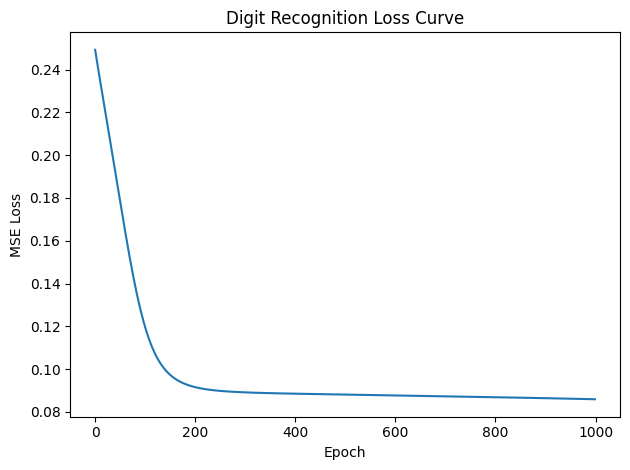

In [20]:
plt.plot(losses_dig)
plt.title("Digit Recognition Loss Curve")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.tight_layout(); plt.show()

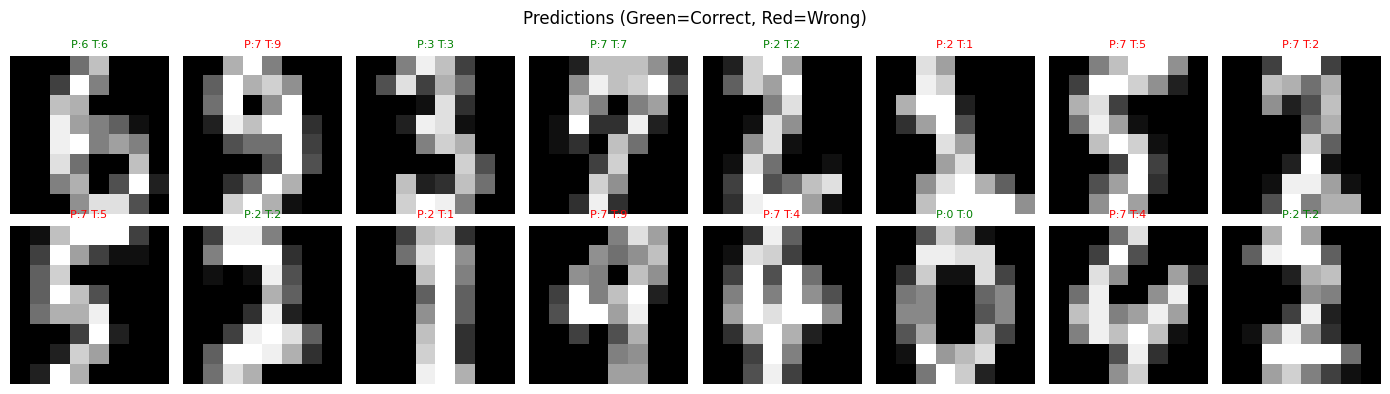

In [21]:
preds = mlp_dig.predict(X_te)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img = X_te[i].reshape(8, 8)
    true_label = y_te_raw[i]
    pred_label = preds[i]
    ax.imshow(img, cmap='gray')
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"P:{pred_label} T:{true_label}", fontsize=8, color=color)
    ax.axis('off')
plt.suptitle("Predictions (Green=Correct, Red=Wrong)")
plt.tight_layout(); plt.show()

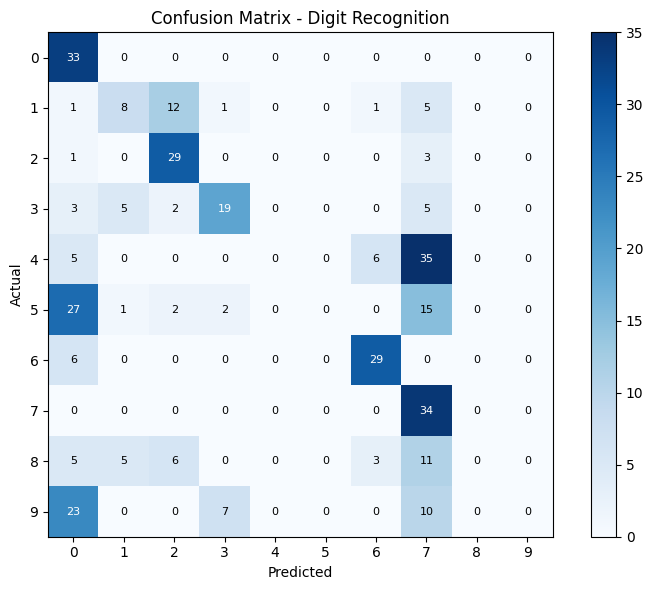

In [22]:
cm = np.zeros((10, 10), dtype=int)
for t, p in zip(y_te_raw, preds):
    cm[t][p] += 1

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(10)); plt.yticks(range(10))
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix - Digit Recognition")
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=8,
                 color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.tight_layout(); plt.show()